In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("data/cicids2017_full.parquet")
print(df.shape)
df.head()

(2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
print("Colonnes:", df.columns.tolist())
print("\nValeurs manquantes:\n", df.isna().sum()[df.isna().sum() > 0])
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nValeurs infinies:", (df[numeric_cols] == np.inf).sum().sum() + (df[numeric_cols] == -np.inf).sum().sum())

Colonnes: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE 

Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64

Proportion:
 Label
BENIGN                          80.300366
DoS Hulk                         8.162981
PortScan                         5.614427
DDoS                             4.522735
DoS GoldenEye                    0.363615
FTP-Patator                      0.280421
SSH-Patator                      0.208320
DoS slowloris                    0.204752
DoS Slowhttp

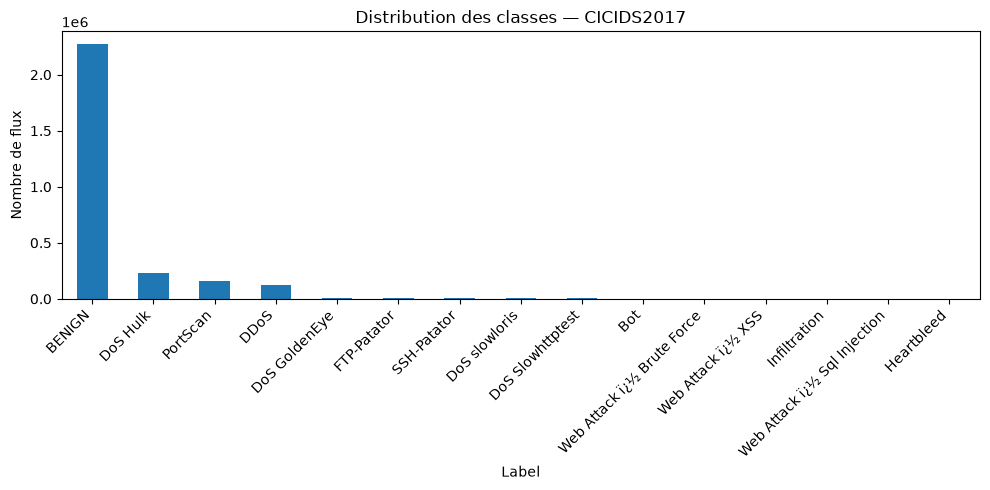

In [9]:
print(df['Label'].value_counts())
print("\nProportion:\n", df['Label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(10,5))
df['Label'].value_counts().plot(kind='bar')
plt.title("Distribution des classes — CICIDS2017")
plt.ylabel("Nombre de flux")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("logs/class_distribution.png")
plt.show()

In [10]:
FEATURES = [
    'Destination Port', 'Flow Duration',
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean',
    'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'FIN Flag Count', 'PSH Flag Count',
    'Flow Bytes/s', 'Flow Packets/s',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward'
]

missing = [f for f in FEATURES if f not in df.columns]
print("Colonnes manquantes :", missing)   # doit afficher []

Colonnes manquantes : []


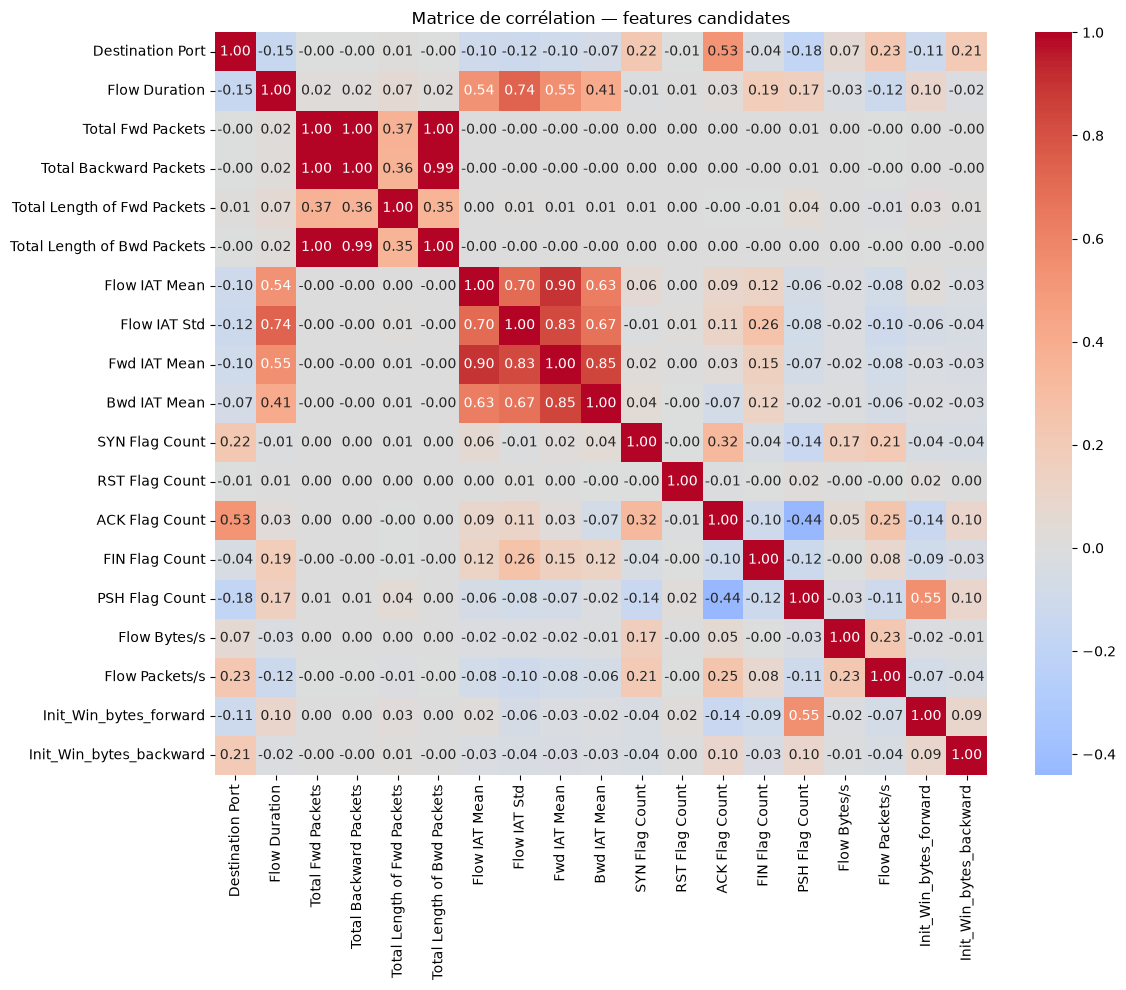

In [11]:
valid_features = [f for f in FEATURES if f in df.columns]
corr = df[valid_features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation — features candidates")
plt.tight_layout()
plt.savefig("logs/correlation_matrix.png")
plt.show()

In [12]:
FEATURES = [
    'Destination Port', 'Flow Duration',
    'Total Fwd Packets', 'Total Length of Fwd Packets',
    'Flow IAT Mean',
    'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count',
    'FIN Flag Count', 'PSH Flag Count',
    'Flow Bytes/s', 'Flow Packets/s',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward'
]
print(f"{len(FEATURES)} features retenues (redondances éliminées)")

14 features retenues (redondances éliminées)
